In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("outputs/train_landmarks.csv")
print(df.shape) # Deve imprimir algo como (N, 85)

# remover nothing
df = df[df["label"] != "nothing"].copy()

print(df.shape)
print(df["label"].value_counts().sort_index())

(7672, 85)
(7672, 85)
label
A    300
B    300
C    290
D    296
E    300
F    300
G    300
H    300
I    296
J    271
K    297
L    299
M    298
N    287
O    299
P    277
Q    281
R    294
S    297
T    300
U    296
V    299
W    300
X    300
Y    299
Z    296
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["label"])
y = df["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

In [4]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [5]:
# from sklearn.neural_network import MLPClassifier
# from sklearn.metrics import accuracy_score, f1_score, classification_report
# """
# mlp = MLPClassifier(
#     hidden_layer_sizes=(256, 128, 64),
#     activation="relu",
#     solver="adam",
#     batch_size=128,
#     learning_rate_init=1e-3,
#     max_iter=200,
#     early_stopping=True,
#     validation_fraction=0.1,
#     n_iter_no_change=10,
#     random_state=42,
#     verbose=True
# )

# mlp.fit(X_train_scaled, y_train_enc)
# """


# mlp = MLPClassifier(
#     hidden_layer_sizes=(128, 64, 32), # Aumentamos as camadas para lidar com as 84 features
#     max_iter=1000, 
#     activation='relu',
#     solver='adam',
#     random_state=42,
#     early_stopping=True, # Ajuda a evitar que o modelo "decore" o ruído (overfitting)
#     validation_fraction=0.1
# )
# # Treine o modelo com o novo X (que agora tem as distâncias extraídas)
# mlp.fit(X_train_scaled, y_train)


# val_pred = mlp.predict(X_val_scaled)
# print("Validation Accuracy:", accuracy_score(y_val_enc, val_pred))
# print("Validation Macro F1:", f1_score(y_val_enc, val_pred, average="macro"))
# print(classification_report(y_val_enc, val_pred, target_names=label_encoder.classes_))

In [6]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 1. Definir o modelo
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64), # Camadas maiores para captar detalhes subtis
    max_iter=1000,
    activation='relu',
    solver='adam',
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    # Adiciona isto aos parâmetros do MLP
    tol=1e-5, 
    n_iter_no_change=20
    )

# 2. TREINAR - MUITO IMPORTANTE: usar y_train_enc (e não y_train)
mlp.fit(X_train_scaled, y_train_enc)

# 3. Prever
val_pred = mlp.predict(X_val_scaled)

# 4. Avaliar (agora ambos são numéricos, logo funciona)
print("Validation Accuracy:", accuracy_score(y_val_enc, val_pred))
print("Validation Macro F1:", f1_score(y_val_enc, val_pred, average="macro"))
print(classification_report(y_val_enc, val_pred, target_names=label_encoder.classes_))

Validation Accuracy: 0.9791485664639444
Validation Macro F1: 0.9791130677176793
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        45
           B       1.00      1.00      1.00        45
           C       1.00      0.98      0.99        44
           D       0.98      1.00      0.99        45
           E       1.00      0.89      0.94        45
           F       1.00      1.00      1.00        45
           G       0.98      1.00      0.99        45
           H       1.00      1.00      1.00        45
           I       0.98      0.98      0.98        45
           J       0.98      1.00      0.99        40
           K       0.98      1.00      0.99        44
           L       1.00      1.00      1.00        45
           M       0.95      0.91      0.93        44
           N       0.85      0.95      0.90        43
           O       0.98      1.00      0.99        45
           P       0.98      1.00      0.99        42
 

In [7]:
test_pred = mlp.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test_enc, test_pred))
print("Test Macro F1:", f1_score(y_test_enc, test_pred, average="macro"))
print(classification_report(y_test_enc, test_pred, target_names=label_encoder.classes_))

Test Accuracy: 0.9817549956559514
Test Macro F1: 0.9817913097243551
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        45
           B       1.00      1.00      1.00        45
           C       0.98      1.00      0.99        43
           D       1.00      1.00      1.00        44
           E       1.00      0.89      0.94        45
           F       1.00      1.00      1.00        45
           G       1.00      0.98      0.99        45
           H       1.00      1.00      1.00        45
           I       0.98      1.00      0.99        44
           J       1.00      1.00      1.00        41
           K       0.96      0.98      0.97        45
           L       1.00      1.00      1.00        45
           M       0.93      0.93      0.93        45
           N       0.91      0.91      0.91        43
           O       1.00      0.96      0.98        45
           P       1.00      1.00      1.00        41
           Q 

In [8]:
import joblib
import os

os.makedirs("models", exist_ok=True)
joblib.dump(mlp, "models/mlp_asl_landmarks.joblib")
joblib.dump(scaler, "models/scaler_asl_landmarks.joblib")
joblib.dump(label_encoder, "models/label_encoder_asl_landmarks.joblib")
print("Modelo e Scaler atualizados com 84 features!")

Modelo e Scaler atualizados com 84 features!


In [9]:
df_ext = pd.read_csv("outputs/test_landmarks.csv")

X_ext = df_ext.drop(columns=["label"])
y_ext = df_ext["label"]

# manter só labels conhecidas do modelo
df_ext = df_ext[df_ext["label"].isin(label_encoder.classes_)].copy()

X_ext = df_ext.drop(columns=["label"])
y_ext = df_ext["label"]

y_ext_enc = label_encoder.transform(y_ext)
X_ext_scaled = scaler.transform(X_ext)

ext_pred = mlp.predict(X_ext_scaled)

from sklearn.metrics import accuracy_score, f1_score, classification_report
print("External Accuracy:", accuracy_score(y_ext_enc, ext_pred))
print("External Macro F1:", f1_score(y_ext_enc, ext_pred, average="macro"))
print(classification_report(y_ext_enc, ext_pred, target_names=label_encoder.classes_))

External Accuracy: 0.7444816053511706
External Macro F1: 0.7093641865729927
              precision    recall  f1-score   support

           A       0.83      0.65      0.73        46
           B       1.00      0.99      0.99        69
           C       0.86      0.34      0.49        53
           D       0.67      0.97      0.79        70
           E       1.00      0.60      0.75        52
           F       0.92      0.99      0.95        70
           G       0.67      0.91      0.77        69
           H       0.97      1.00      0.99        68
           I       0.79      0.92      0.85        66
           J       0.94      0.83      0.88        41
           K       0.86      0.79      0.82        70
           L       0.97      0.87      0.92        70
           M       0.23      0.39      0.29        33
           N       0.33      0.51      0.40        35
           O       0.53      0.52      0.53        50
           P       0.86      0.97      0.91        69
     

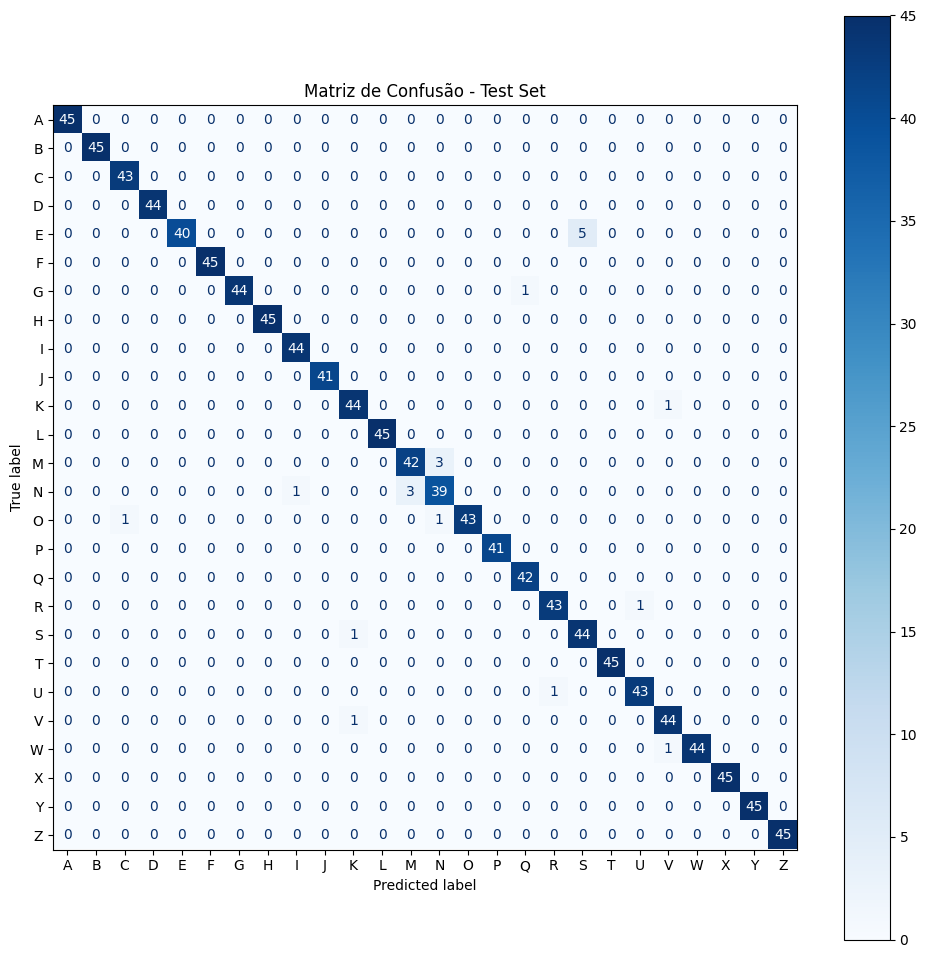

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Gerar previsões APENAS para o conjunto de teste (X_test_scaled)
# Isto vai garantir que y_pred tenha 1535 amostras, tal como o y_test_enc
y_pred = mlp.predict(X_test_scaled)

# 2. Criar a matriz usando y_test_enc (os números) e y_pred (as previsões)
cm = confusion_matrix(y_test_enc, y_pred)

# 3. Desenhar a matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - Test Set")
plt.show()